In [2]:
import os
import pandas as pd
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
# Load our CSV files
train_df = pd.read_csv("../preprocessing/splits/train.csv")
val_df = pd.read_csv("../preprocessing/splits/validation.csv")
test_df = pd.read_csv("../preprocessing/splits/test.csv")

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 1260
Validation: 270
Test: 270


In [4]:
# Image size
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_CLASSES = 5

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", NUM_CLASSES)

Image size: (224, 224)
Batch size: 16
Classes: 5


In [5]:
# Image loading function
def load_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(image, tf.float32)

    return image, label

In [6]:
# Dataset create
train_paths = train_df["image_path"].values
train_labels = train_df["label"].values

val_paths = val_df["image_path"].values
val_labels = val_df["label"].values

test_paths = test_df["image_path"].values
test_labels = test_df["label"].values

In [7]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

In [8]:
# Apply preprocessing
train_ds = train_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [9]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10)
])

In [10]:
# Batch + Prefetch
train_ds = train_ds.batch(BATCH_SIZE).prefetch(
    tf.data.AUTOTUNE
)

val_ds = val_ds.batch(BATCH_SIZE).prefetch(
    tf.data.AUTOTUNE
)

test_ds = test_ds.batch(BATCH_SIZE).prefetch(
    tf.data.AUTOTUNE
)

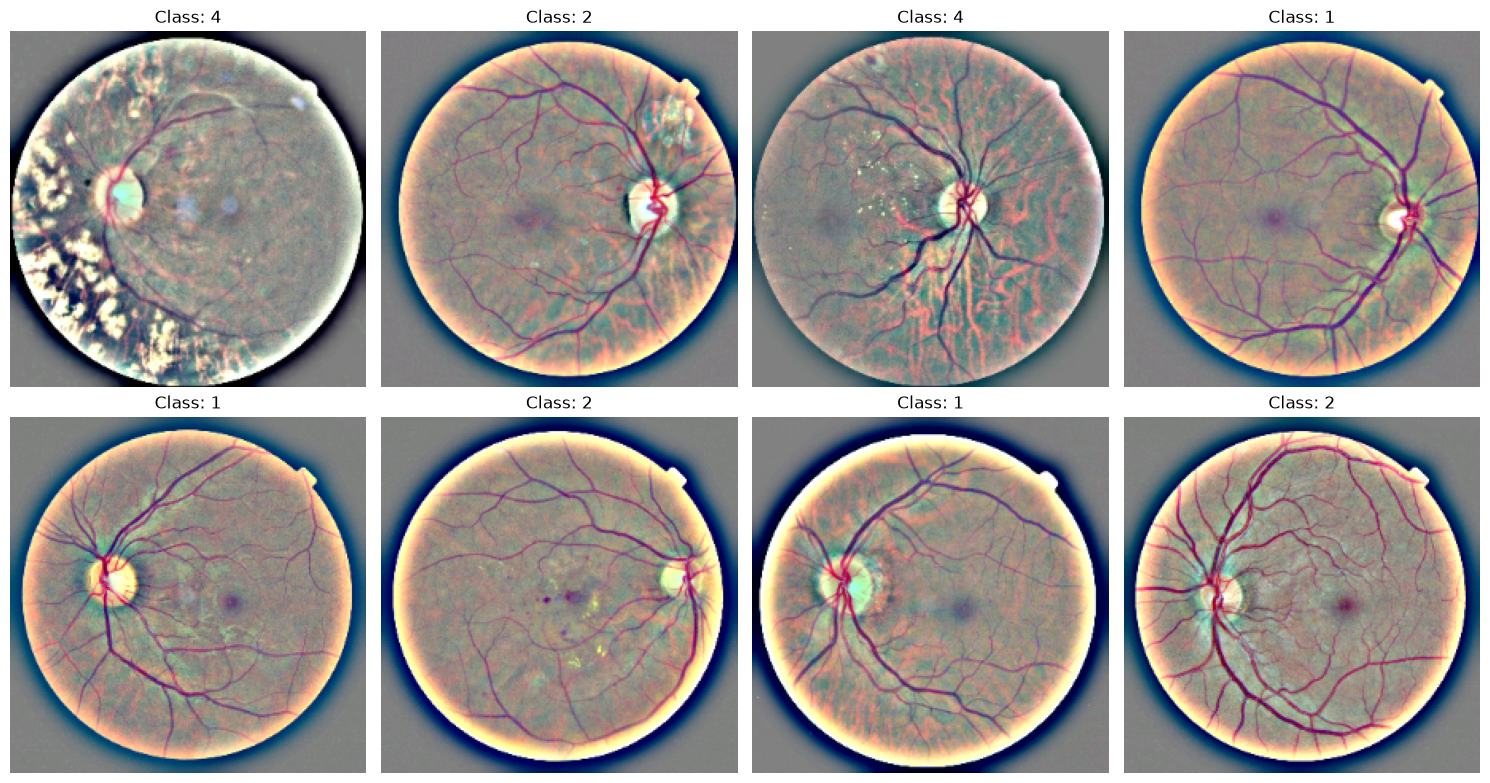

In [11]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 8))

images, labels = next(iter(train_ds))

for i in range(min(8, len(images))):

    image = images[i].numpy()

    # Display only: convert 0-255 to 0-1
    image = image / 255.0

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(f"Class: {labels[i].numpy()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [23]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "../model/efficientnetv2_best.keras"
)

print("Model loaded successfully!")

Model loaded successfully!


In [24]:
# Test Set Evaluation

test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 443ms/step - accuracy: 0.4481 - loss: 1.2246
Test Loss     : 1.2245556116104126
Test Accuracy : 0.4481481611728668
